# Comparing optimal paths between mazes (barrier change sessions)

For a barrier change session, we're often interested in the rat's choice between the previously-optimal path on the old maze and the now-optimal path on the new maze.

This tutorial covers functions for identifying where paths diverge and converge, the shared hexes before the choice point, and the hexes unique to each path.

## Useful functions
All of the following functions take parameters `old_maze`, `new_maze`, `start_port`, `end_port`. For getting hexes before/after divergence, optional argument `distance_from_divergence` restricts hexes to those within a certain hex distance of the divergence point.

### `get_path_divergence_point`: last shared hex before the old/new paths diverge

### `get_path_convergence_point`: first shared hex between the old/new paths afetr they come back together

### `get_hexes_before_divergence`: gets all hexes before the divergence point between paths (not restricted to optimal paths)

When the rat is deciding between paths, we may want to see what he is thinking about while he is in the hexes before the old and new paths diverge. `get_hexes_before_divergence` returns all hexes between the start port and the divergence point. These are the hexes the rat traverses before it has to choose between the old and new paths. Set `dead_end_ok=False` or `non_optimal_ok=False` to restrict to only optimal-path hexes (both True by default). 

Note that the hexes before path divergence point depends on direction (e.g. port 1 to 2 vs port 2 to 1), so both directions are shown below. For hexes after path convergence, this is the same as hexes before divergence with the start/end port switched.


Note that this uses the most similar pair of old/new paths between ports.

### `get_hexes_after_divergence`: gets all hexes within a certain distance from the divergence point in the old/new path direction (not restricted to optimal paths)

Does a breadth-first search from the divergence point into the old and new path directions, up to a specified distance (argument `distance`, default 5). This allows us to identify hexes in the old and new path directions (even if they are not on the old/new optimal paths between ports). Hexes before the divergence and after the convergence point are excluded so the search only expands into the region between the two. 

Note that hexes after the path convergence point are excluded (because they are on both optimal paths). Hexes that can be reached from either path (but are not on optimal paths) are assigned to the closer path. If equidistant, they are excluded from both.


### `get_optimal_path_hexes_after_divergence` : gets hexes unique to the old optimal path, hexes unique to the new optimal path between ports

Optional argument `distance_from_divergence` restricts to hexes only within a certain hex distance of the divergence point. Defaults to no restriction (all hexes on old optimal path, all hexes on new optimal path)


# 1. Show hexes on old and new optimal paths between ports 

Maze 1: frozenset({np.int64(37), np.int64(7), np.int64(42), np.int64(44), np.int64(14), np.int64(20), np.int64(25), np.int64(28), np.int64(31)})
Maze 2: frozenset({37, 7, 42, 44, 14, 17, 20, 25, 28})

Port 1 to Port 2:
Old paths: [[1, 4, 6, 8, 10, 13, 17, 21, 26, 22, 27, 32, 38, 49, 2]]
New paths: [[1, 4, 6, 8, 10, 13, 16, 12, 15, 19, 24, 29, 35, 30, 36, 31, 26, 22, 27, 32, 38, 49, 2]]
Paths diverge at hex 13, converge at hex 26
Unique hexes on old path: {17, 21}
Unique hexes on new path: {35, 36, 12, 15, 16, 19, 24, 29, 30, 31}

Port 1 to Port 3:
Old paths: [[1, 4, 6, 8, 10, 13, 16, 12, 15, 19, 24, 29, 34, 39, 43, 48, 3]]
New paths: [[1, 4, 6, 8, 10, 13, 16, 12, 15, 19, 24, 29, 34, 39, 43, 48, 3]]
Paths diverge at hex None, converge at hex None
Unique hexes on old path: set()
Unique hexes on new path: set()

Port 2 to Port 3:
Old paths: [[2, 49, 38, 32, 27, 22, 26, 21, 17, 13, 16, 12, 15, 19, 24, 29, 34, 39, 43, 48, 3]]
New paths: [[2, 49, 38, 32, 27, 22, 26, 31, 36, 30, 35, 29, 34, 3

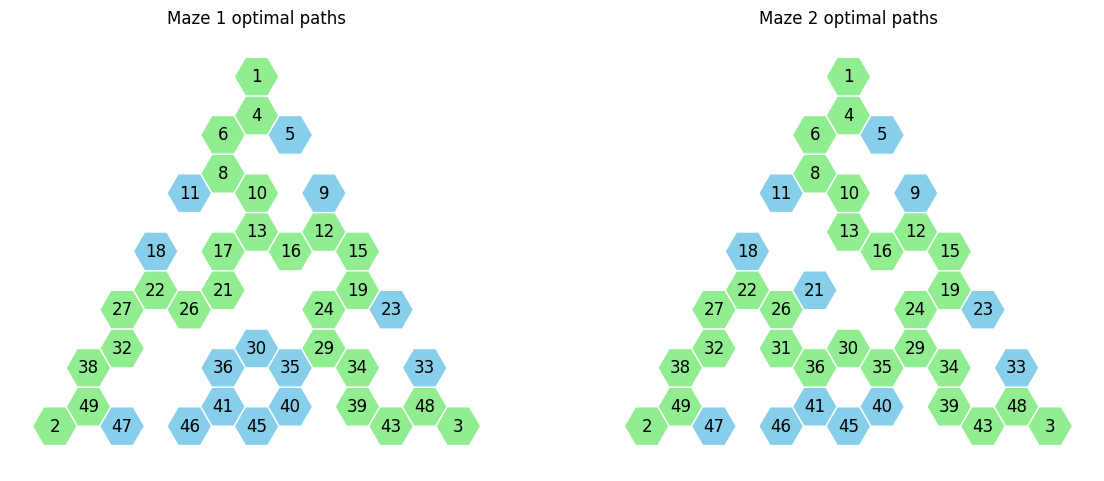

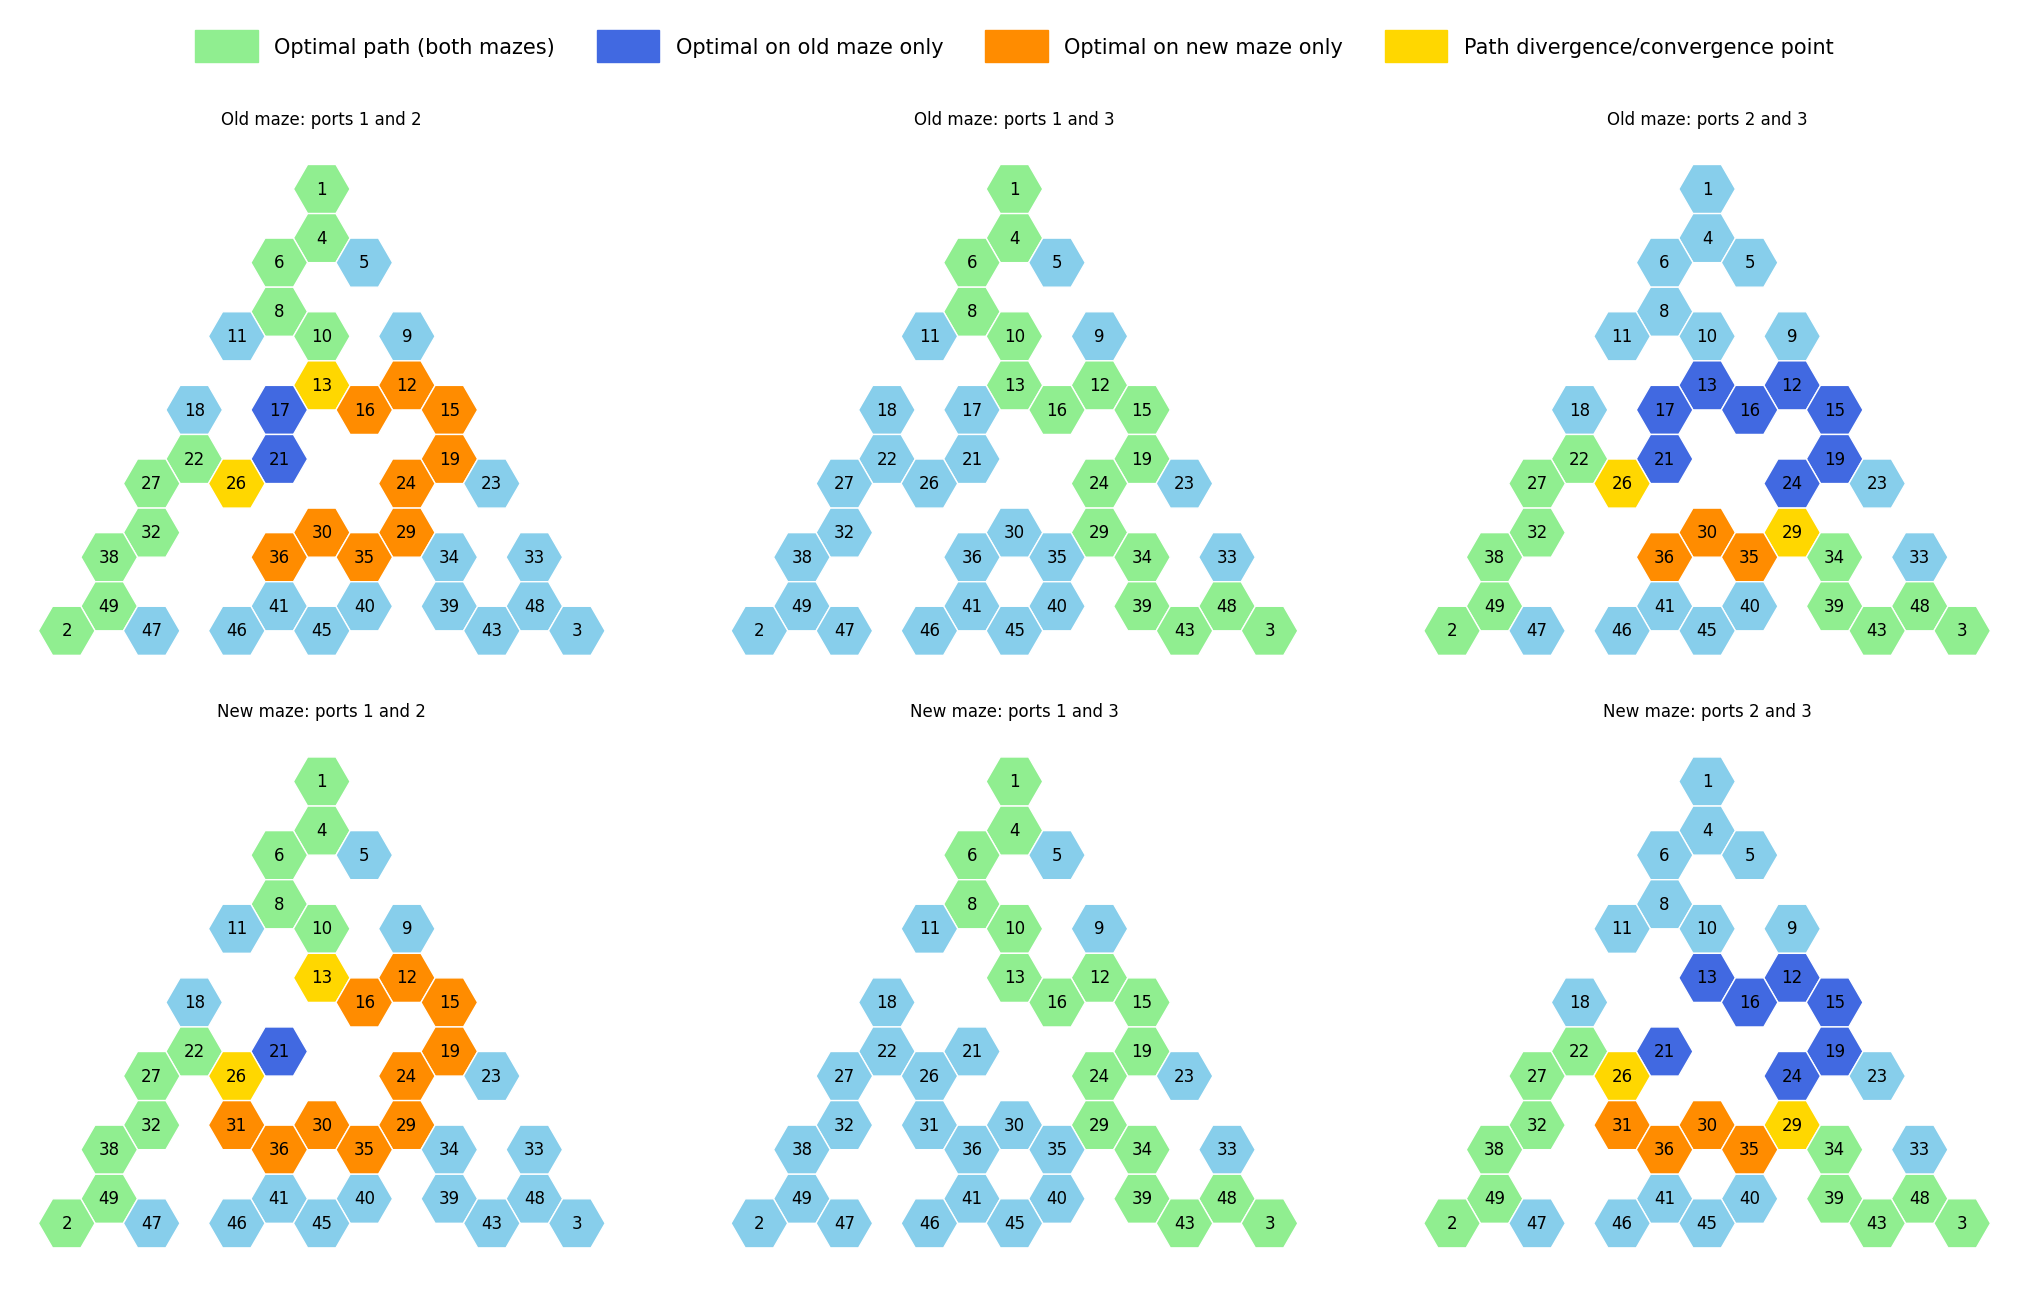

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import sys
sys.path.append("..") # Use sys to add the parent directory (where src/hexmaze lives) to the path

from src.hexmaze import (
    plot_hex_maze,
    get_all_path_pairs,
    get_old_and_new_paths,
    get_path_divergence_point,
    get_path_convergence_point,
    get_hexes_before_divergence,
    get_optimal_path_hexes_after_divergence,
    get_hexes_after_divergence,
    get_optimal_paths,
)

# Load the barrier sequence database and grab 2 mazes that differ by one barrier
barrier_sequence_database = pd.read_pickle('../Barrier_Sequence_Databases/barrier_sequence_database.pkl')
sequence = barrier_sequence_database.iloc[3]['barrier_sequence']
maze_1, maze_2 = sequence[0], sequence[1]

# Plot the 2 mazes with optimal paths shown
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].set_title("Maze 1 optimal paths")
print(f"Maze 1: {maze_1}")
plot_hex_maze(maze_1, ax=axes[0], show_barriers=False, show_optimal_paths=True)
axes[1].set_title("Maze 2 optimal paths")
plot_hex_maze(maze_2, ax=axes[1], show_barriers=False, show_optimal_paths=True)
print(f"Maze 2: {maze_2}")

# Compare old vs new optimal paths for each port pair
fig, axes = plt.subplots(2, 3, figsize=(21, 12))

for i, (start, end) in enumerate([(1, 2), (1, 3), (2, 3)]):
    # Hex where optimal paths between these ports diverge
    divergence_point = get_path_divergence_point(maze_1, maze_2, start, end)
    # Hex where optimal paths between these ports converge (aka divergence point if start/end port order was switched)
    convergence_point = get_path_convergence_point(maze_1, maze_2, start, end)
    # Get the old and new optimal paths between ports
    old_paths, new_paths = get_old_and_new_paths(maze_1, maze_2, start, end)
    # Get hexes unique to the old and new path between ports (between divergence/convergence)
    hexes_on_old_path, hexes_on_new_path = get_optimal_path_hexes_after_divergence(maze_1, maze_2, start, end)
    print(f"\nPort {start} to Port {end}:")
    print(f"Old paths: {old_paths}")
    print(f"New paths: {new_paths}")
    print(f"Paths diverge at hex {divergence_point}, converge at hex {convergence_point}")
    print(f"Unique hexes on old path: {hexes_on_old_path}")
    print(f"Unique hexes on new path: {hexes_on_new_path}")
    
    # Highlight optimal paths between ports in light green
    # (because differing hexes on optimal paths will be overridden by subsequent highlights,
    # we can use get_optimal_paths for maze_1 and use it for both maze 1 and 2)
    optimal_paths = get_optimal_paths(maze_1, start, end)
    optimal_path_hexes = {hex for path in optimal_paths for hex in path}

    # Highlight old path hexes in blue, new path hexes in orange, 
    # and path divergence/convergence points in gold
    path_choice_points = set()
    if divergence_point is not None:
        path_choice_points.add(divergence_point)
    if convergence_point is not None:
        path_choice_points.add(convergence_point)

    highlight = [optimal_path_hexes, hexes_on_old_path, hexes_on_new_path, path_choice_points]
    colors = ["lightgreen", "royalblue", "darkorange", "gold"]

    # Plot the path difference on the old maze
    plot_hex_maze(maze_1, ax=axes[0, i], highlight_hexes=highlight, highlight_colors=colors, show_barriers=False)
    axes[0, i].set_title(f"Old maze: ports {start} and {end}")

    # Plot the path difference on the new maze
    plot_hex_maze(maze_2, ax=axes[1, i], highlight_hexes=highlight, highlight_colors=colors, show_barriers=False)
    axes[1, i].set_title(f"New maze: ports {start} and {end}")

# Define legend handles
legend_handles = [
    mpatches.Patch(color="lightgreen", label="Optimal path (both mazes)"),
    mpatches.Patch(color="royalblue", label="Optimal on old maze only"),
    mpatches.Patch(color="darkorange", label="Optimal on new maze only"),
    mpatches.Patch(color="gold", label="Path divergence/convergence point"),
]

# Add a single shared legend outside the plots
fig.legend(handles=legend_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08), fontsize=15,
    handlelength=3, handleheight=2, borderpad=1, frameon=False,)

plt.tight_layout()
plt.show()


# 2. Show hexes before path divergence point

Port 1 to Port 2: 7 hexes before divergence = {1, 4, 5, 6, 7, 8, 10}
Port 1 to Port 3: 7 hexes before divergence = {1, 4, 5, 6, 7, 8, 10}
Port 2 to Port 3: 0 hexes before divergence = set()


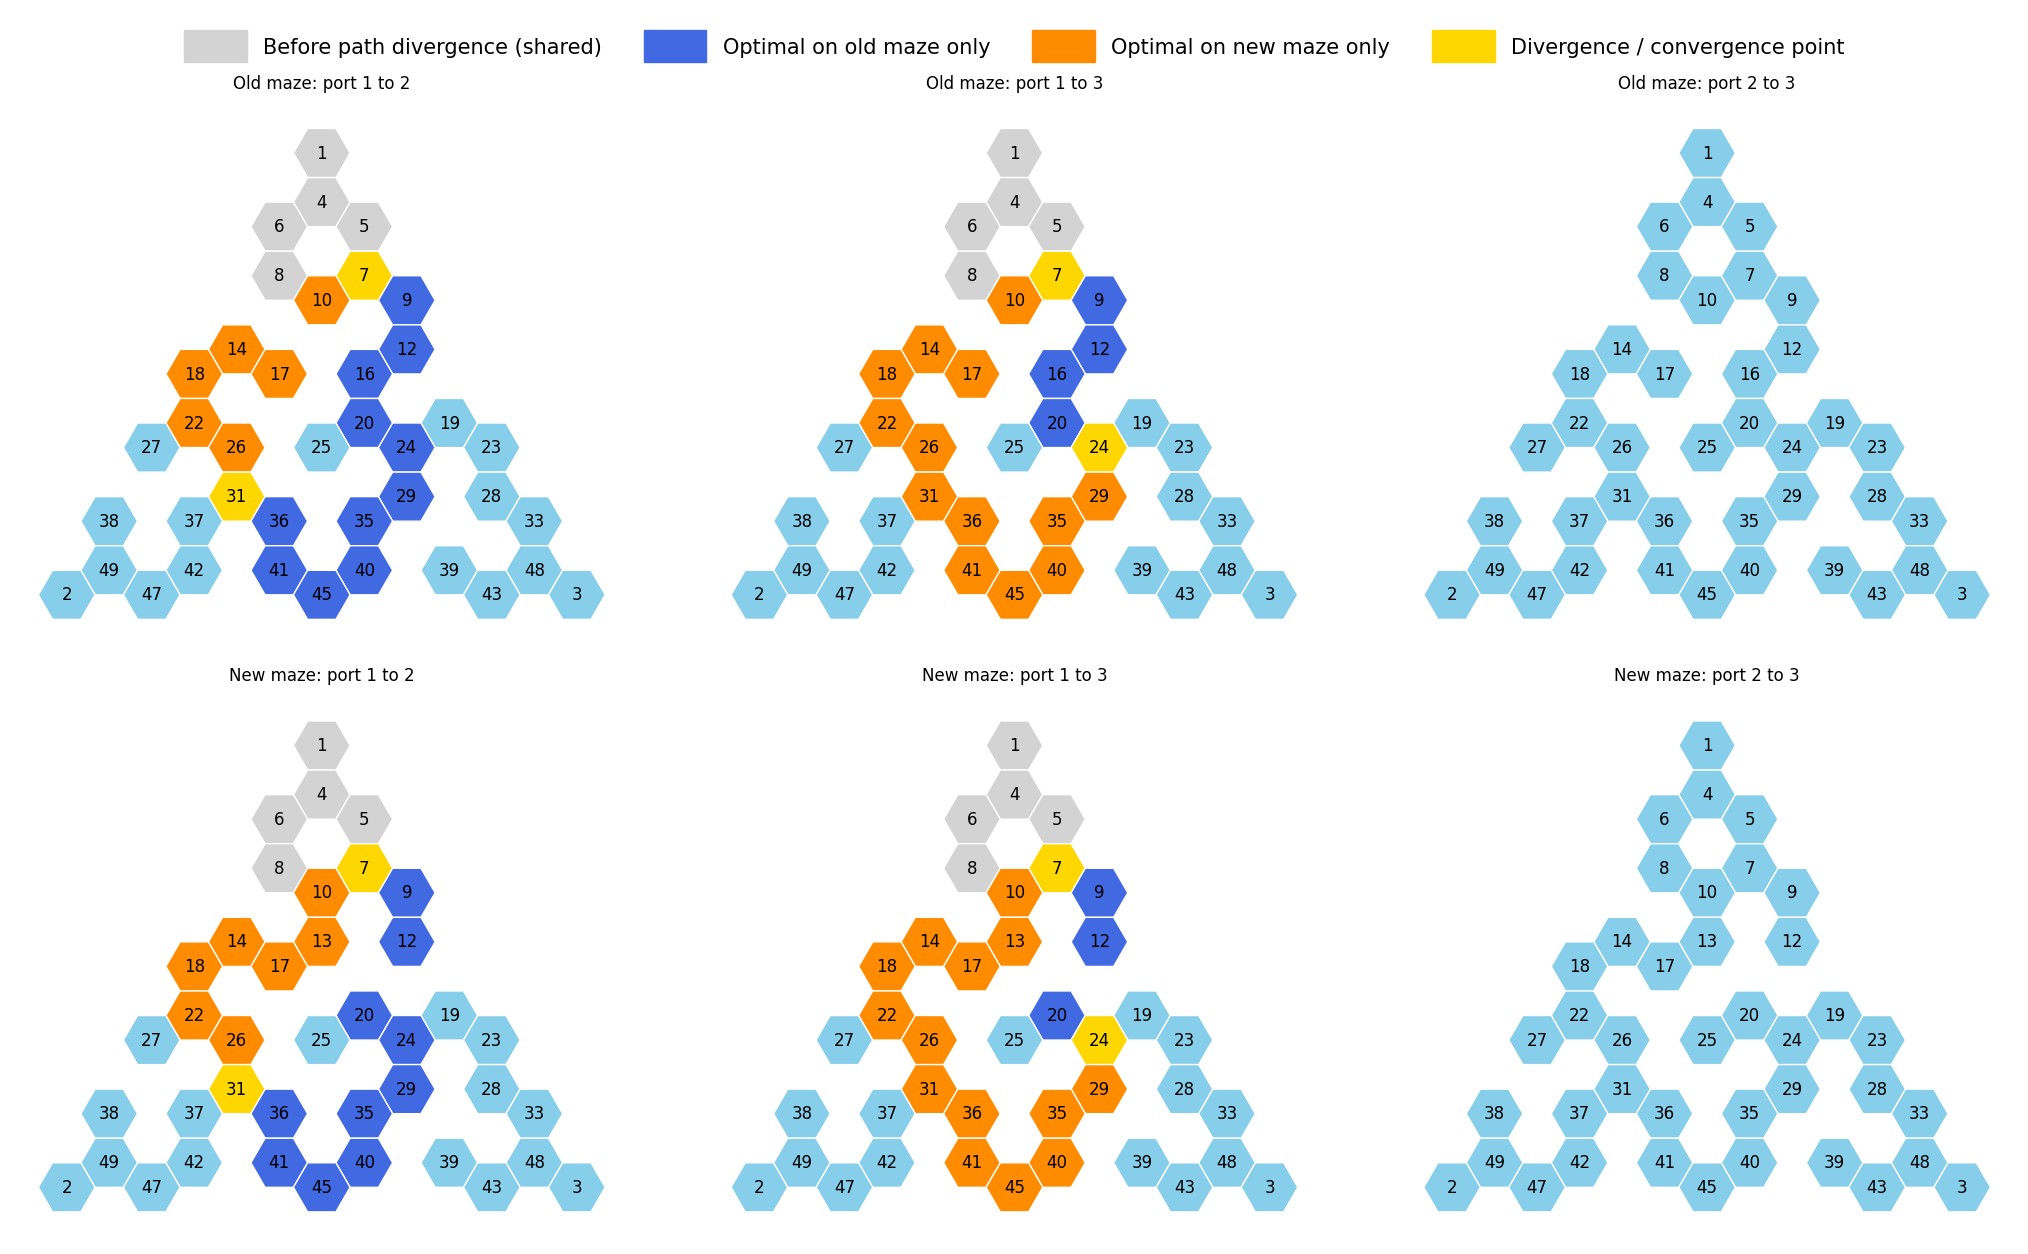

Port 2 to Port 1: 7 hexes before divergence = {49, 2, 37, 38, 42, 47, 31}
Port 3 to Port 1: 9 hexes before divergence = {33, 3, 39, 43, 48, 19, 23, 24, 28}
Port 3 to Port 2: 0 hexes before divergence = set()


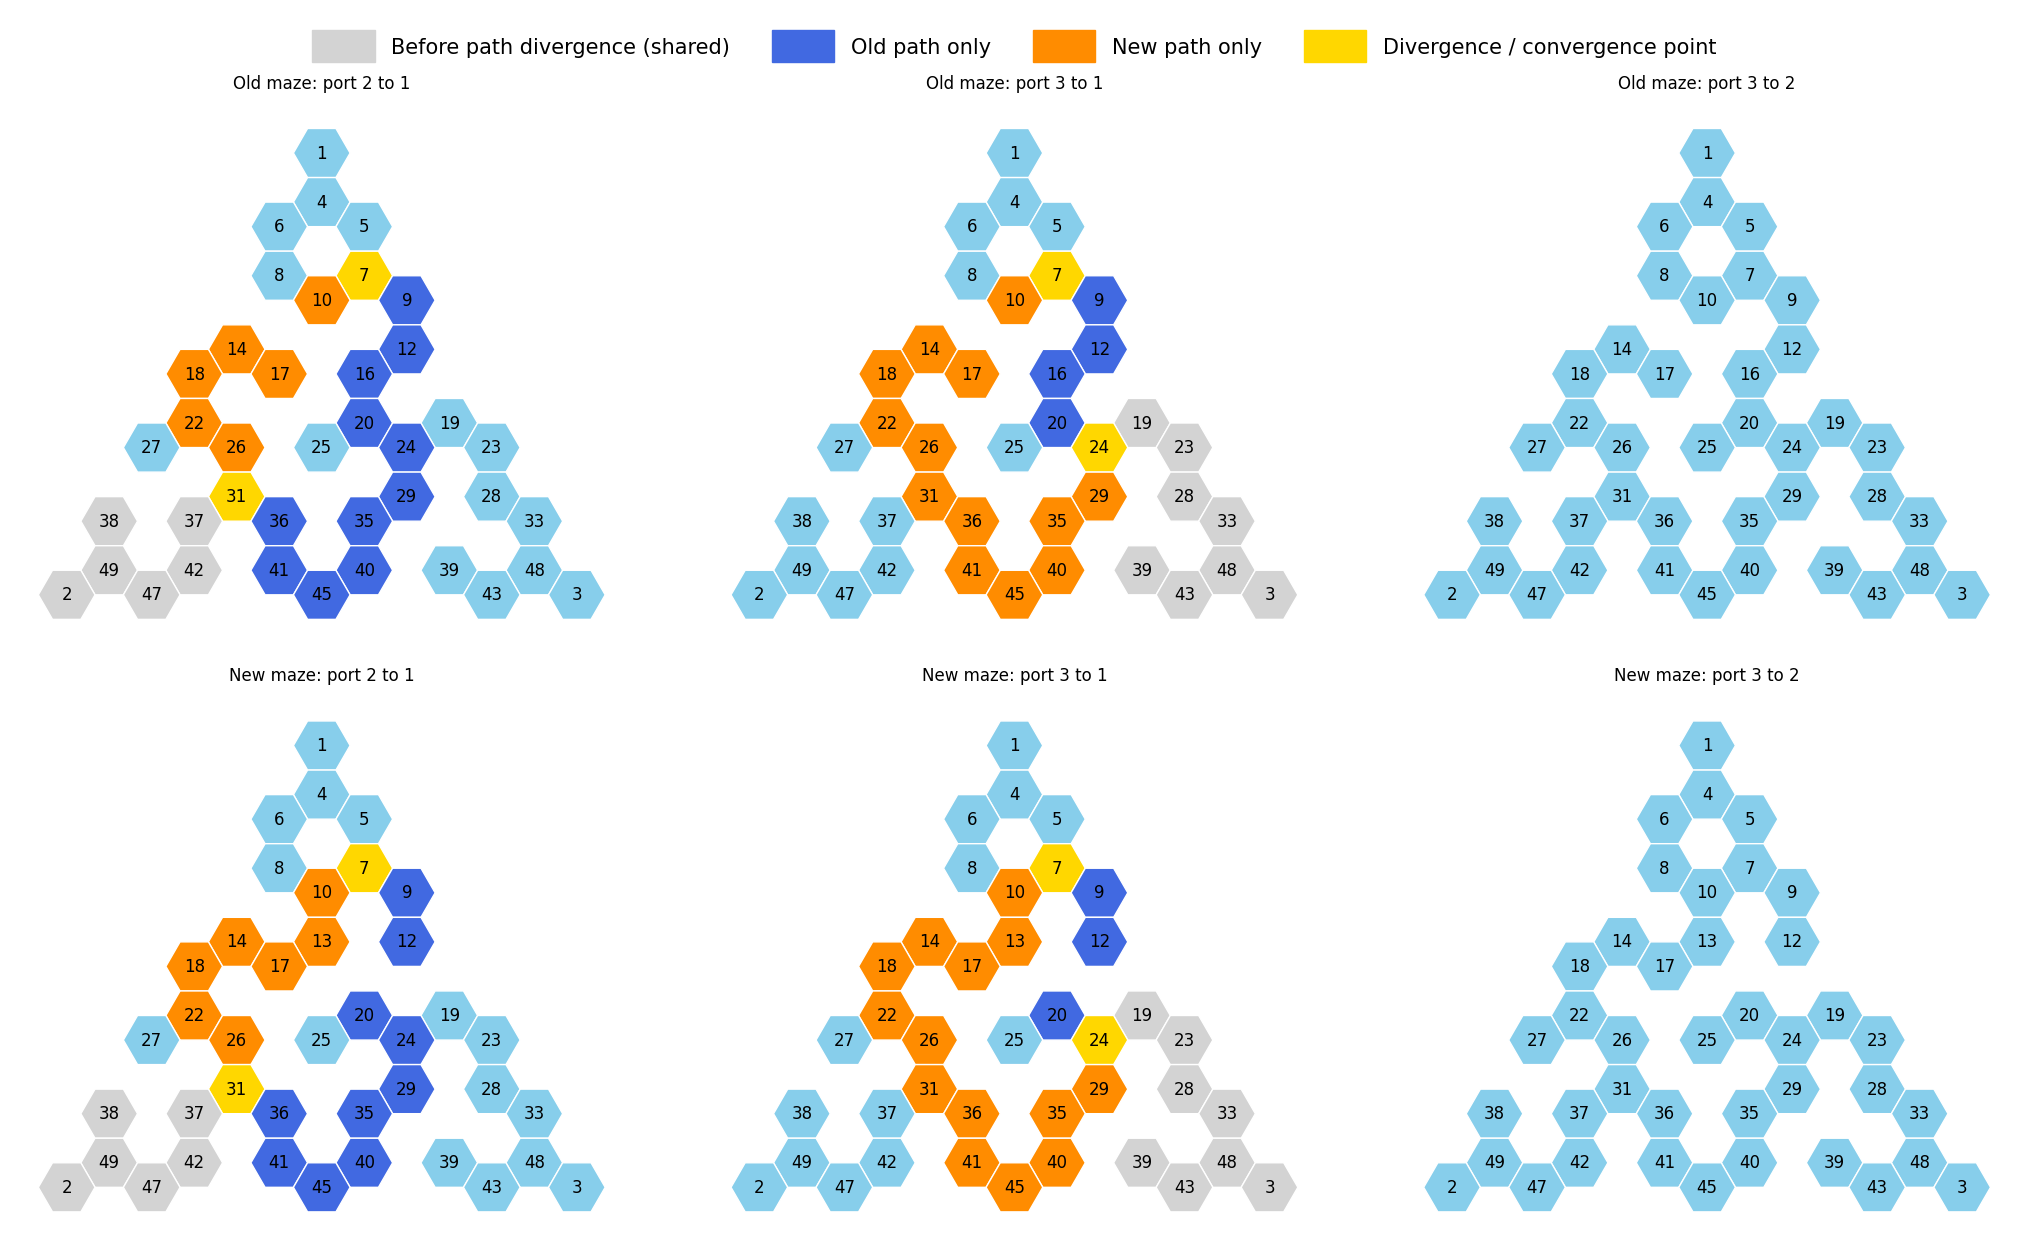

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(21, 12))

# Loop through port pairs
for i, (start, end) in enumerate([(1, 2), (1, 3), (2, 3)]):
    # Get hexes before divergence (including non-optimal and dead ends)
    before_div = get_hexes_before_divergence(maze_1, maze_2, start, end)
    # Get hexes unique to old/new paths
    hexes_on_old_path, hexes_on_new_path = get_optimal_path_hexes_after_divergence(maze_1, maze_2, start, end)

    # Get divergence/convergence point of most similar paths
    divergence_point = get_path_divergence_point(maze_1, maze_2, start, end)
    convergence_point = get_path_convergence_point(maze_1, maze_2, start, end)
    
    # Print set of hexes before divergence
    print(f"Port {start} to Port {end}: {len(before_div)} hexes before divergence = {before_div}")

    key_points = set()
    if divergence_point is not None:
        key_points.add(divergence_point)
    if convergence_point is not None:
        key_points.add(convergence_point)

    # Plot hexes before divergence in light grey, old path in blue,
    # new path in orange, and divergence/convergence hexes in gold
    highlight = [before_div - key_points, hexes_on_old_path, hexes_on_new_path, key_points]
    colors = ["lightgray", "royalblue", "darkorange", "gold"]

    plot_hex_maze(maze_1, ax=axes[0, i], highlight_hexes=highlight,
                  highlight_colors=colors, show_hex_labels=True, show_barriers=False)
    axes[0, i].set_title(f"Old maze: port {start} to {end}")

    plot_hex_maze(maze_2, ax=axes[1, i], highlight_hexes=highlight,
                  highlight_colors=colors, show_hex_labels=True, show_barriers=False)
    axes[1, i].set_title(f"New maze: port {start} to {end}")

legend_handles = [
    mpatches.Patch(color="lightgray", label="Before path divergence (shared)"),
    mpatches.Patch(color="royalblue", label="Optimal on old maze only"),
    mpatches.Patch(color="darkorange", label="Optimal on new maze only"),
    mpatches.Patch(color="gold", label="Divergence / convergence point"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05), fontsize=15,
    handlelength=3, handleheight=2, borderpad=1, frameon=False)
plt.tight_layout()
plt.show()


## Same port pairs but in the other direction
fig, axes = plt.subplots(2, 3, figsize=(21, 12))

# Loop through port pairs (but now switch start and end port)
for i, (start, end) in enumerate([(1, 2), (1, 3), (2, 3)]):
    # Get hexes before divergence (including non-optimal and dead ends)
    before_div = get_hexes_before_divergence(maze_1, maze_2, end, start)
    # Get hexes unique to old/new paths
    hexes_on_old_path, hexes_on_new_path = get_optimal_path_hexes_after_divergence(maze_1, maze_2, end, start)

    # Get divergence/convergence point of most similar paths
    divergence_point = get_path_divergence_point(maze_1, maze_2, end, start)
    convergence_point = get_path_convergence_point(maze_1, maze_2, end, start)
    print(f"Port {end} to Port {start}: {len(before_div)} hexes before divergence = {before_div}")

    key_points = set()
    if divergence_point is not None:
        key_points.add(divergence_point)
    if convergence_point is not None:
        key_points.add(convergence_point)
        
    # Plot hexes before divergence in light grey, old path in blue,
    # new path in orange, and divergence/convergence hexes in gold
    highlight = [before_div - key_points, hexes_on_old_path, hexes_on_new_path, key_points]
    colors = ["lightgray", "royalblue", "darkorange", "gold"]

    plot_hex_maze(maze_1, ax=axes[0, i], highlight_hexes=highlight,
                  highlight_colors=colors, show_hex_labels=True, show_barriers=False)
    axes[0, i].set_title(f"Old maze: port {end} to {start}")

    plot_hex_maze(maze_2, ax=axes[1, i], highlight_hexes=highlight,
                  highlight_colors=colors, show_hex_labels=True, show_barriers=False)
    axes[1, i].set_title(f"New maze: port {end} to {start}")

legend_handles = [
    mpatches.Patch(color="lightgray", label="Before path divergence (shared)"),
    mpatches.Patch(color="royalblue", label="Old path only"),
    mpatches.Patch(color="darkorange", label="New path only"),
    mpatches.Patch(color="gold", label="Divergence / convergence point"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05), fontsize=15,
    handlelength=3, handleheight=2, borderpad=1, frameon=False)
plt.tight_layout()
plt.show()


# 3. Show hexes in old and new path direction after divergence (not restricted to optimal paths)


Port 1 to Port 2 (distance=3):
  Old direction: {17, 21}
  New direction: {16, 9, 12, 15}
Port 1 to Port 3 (distance=3):
  Old direction: set()
  New direction: set()
Port 2 to Port 3 (distance=3):
  Old direction: {17, 13, 21}
  New direction: {41, 36, 30, 31}


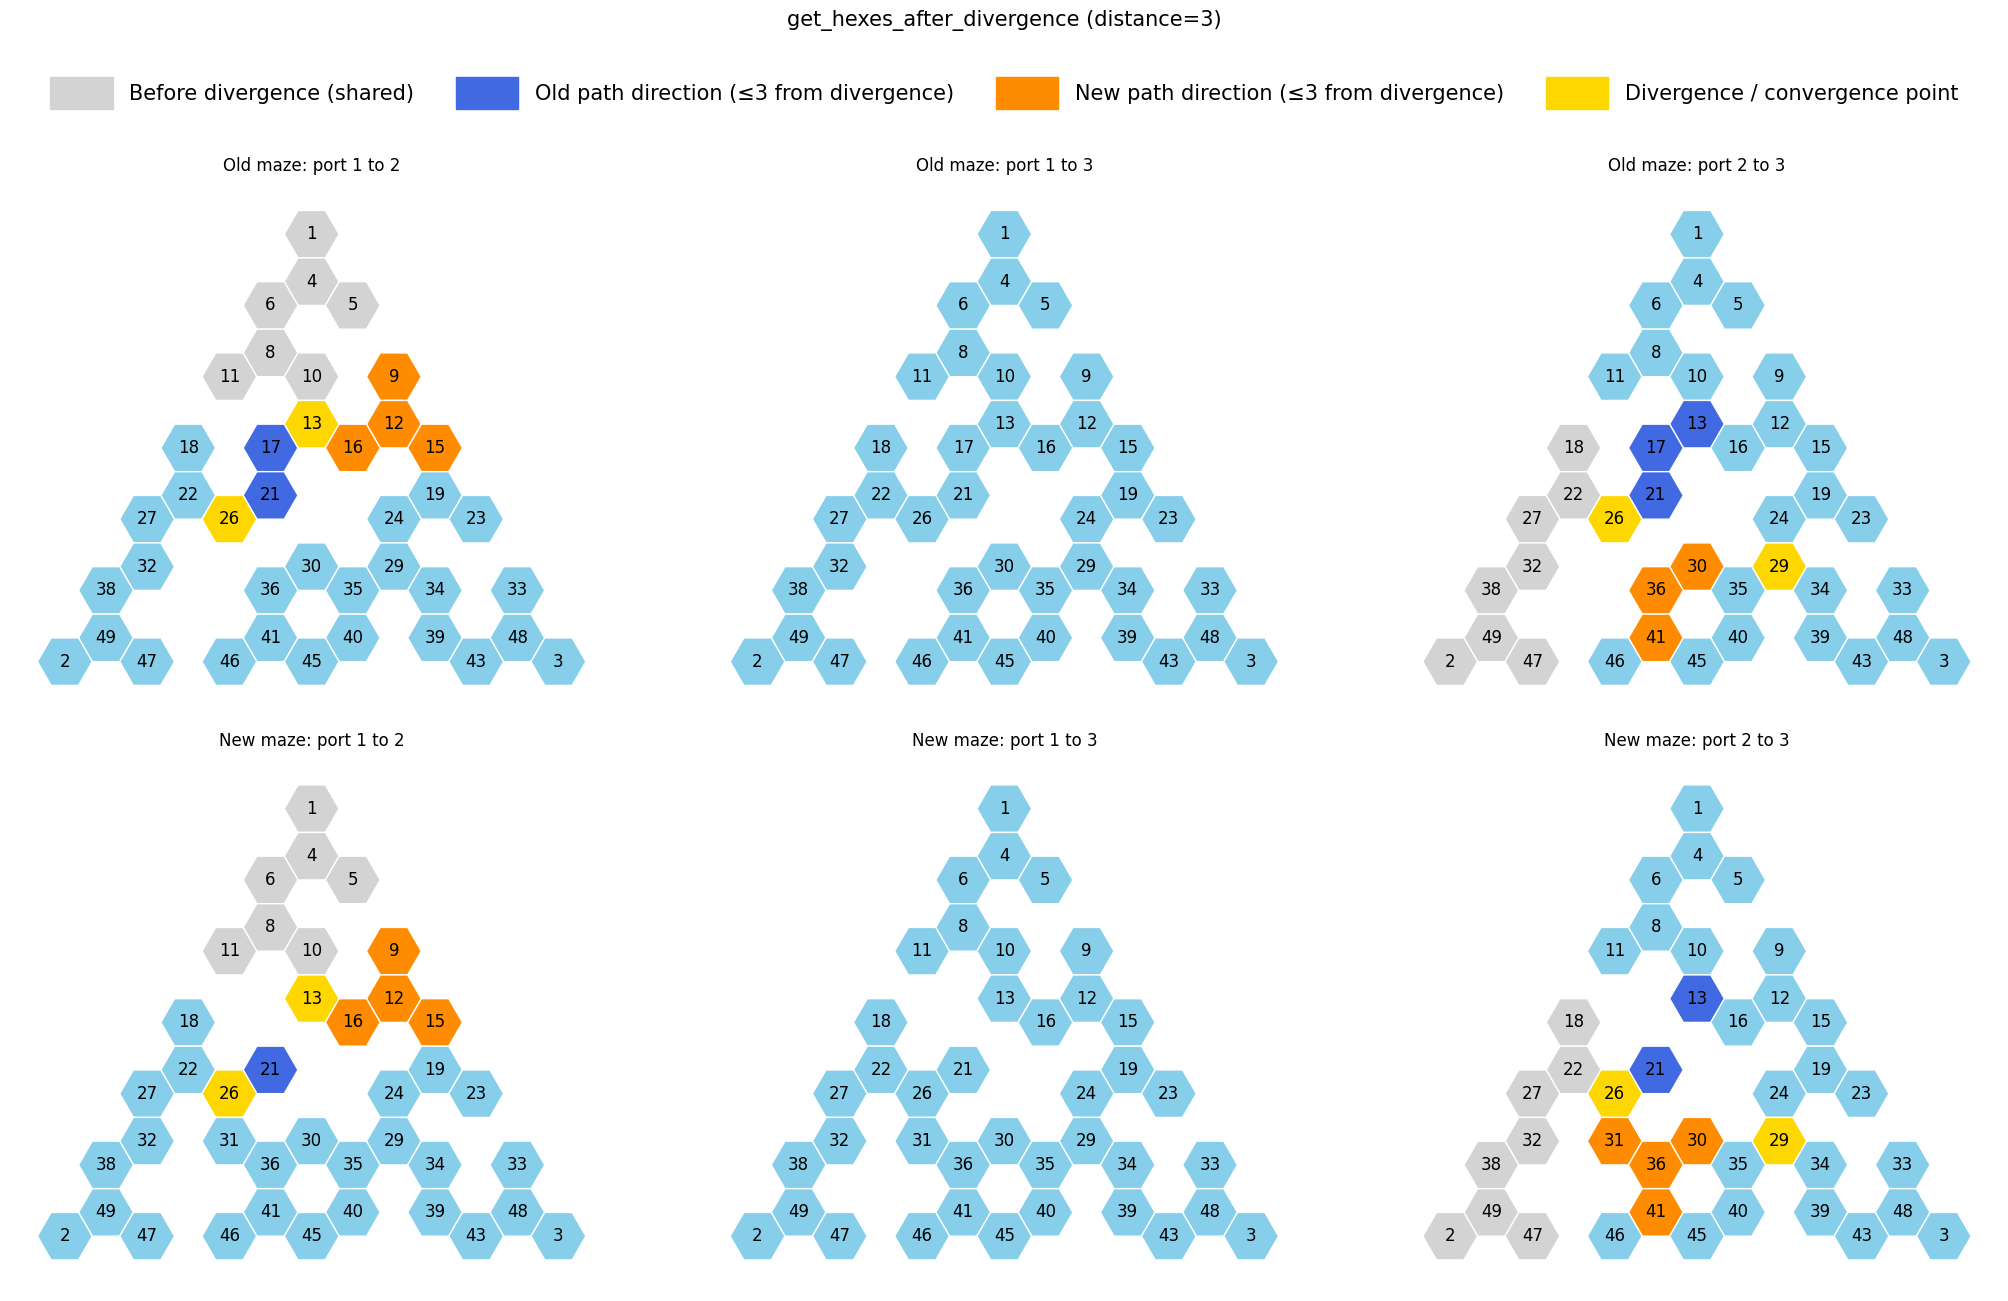

Port 1 to Port 2 (distance=5):
  Old direction: {17, 21}
  New direction: {9, 12, 15, 16, 19, 23, 24}
Port 1 to Port 3 (distance=5):
  Old direction: set()
  New direction: set()
Port 2 to Port 3 (distance=5):
  Old direction: {8, 10, 12, 13, 16, 17, 21}
  New direction: {35, 36, 40, 41, 45, 46, 30, 31}


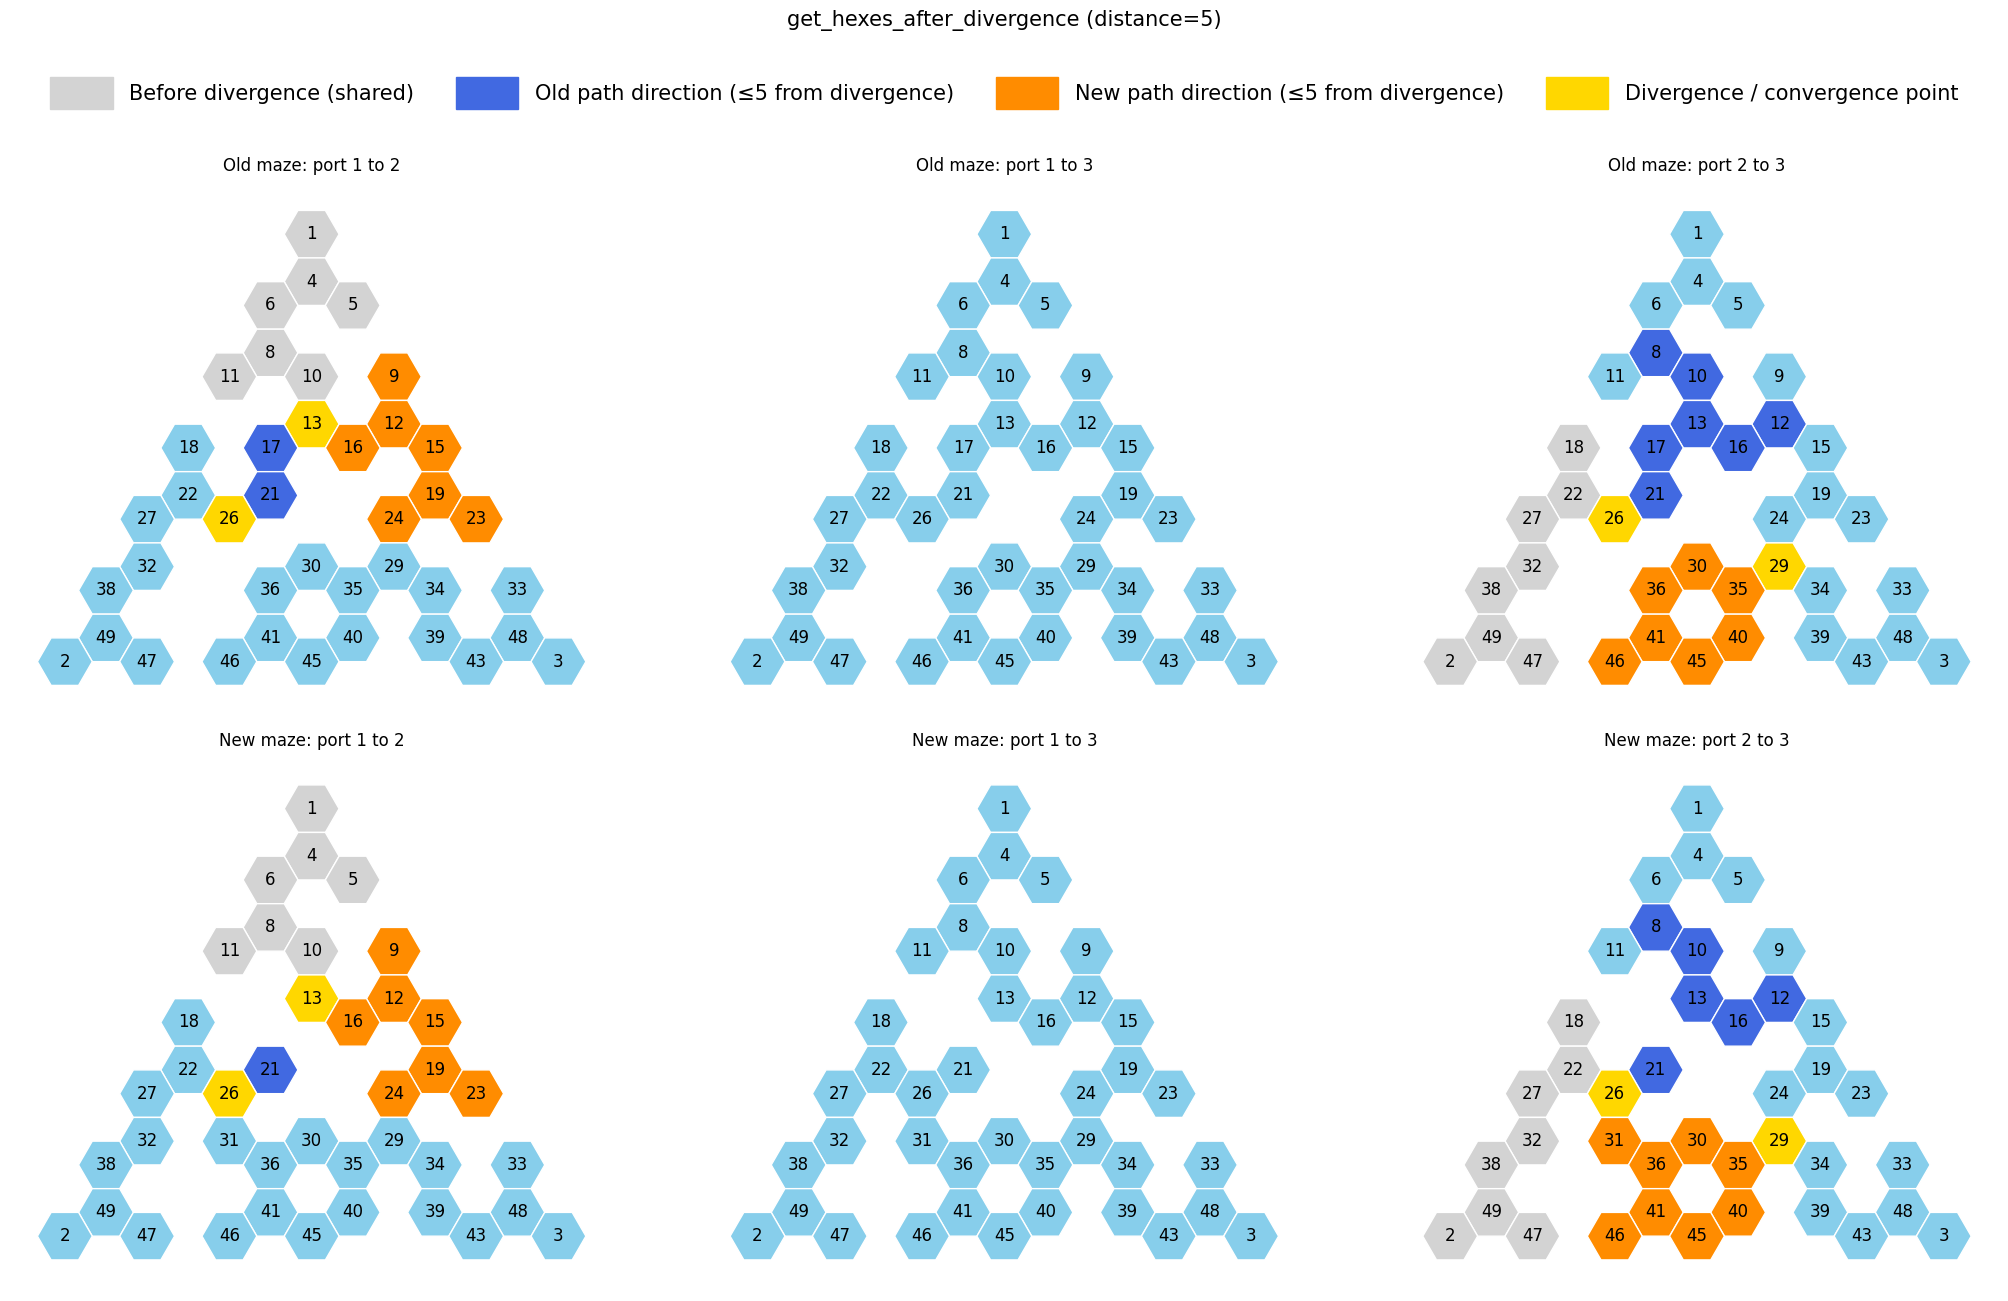

Port 1 to Port 2 (distance=7):
  Old direction: {17, 21}
  New direction: {34, 35, 9, 12, 15, 16, 19, 23, 24, 29}
Port 1 to Port 3 (distance=7):
  Old direction: set()
  New direction: set()
Port 2 to Port 3 (distance=7):
  Old direction: {4, 6, 8, 9, 10, 11, 12, 13, 15, 16, 17, 19, 21}
  New direction: {35, 36, 40, 41, 45, 46, 30, 31}


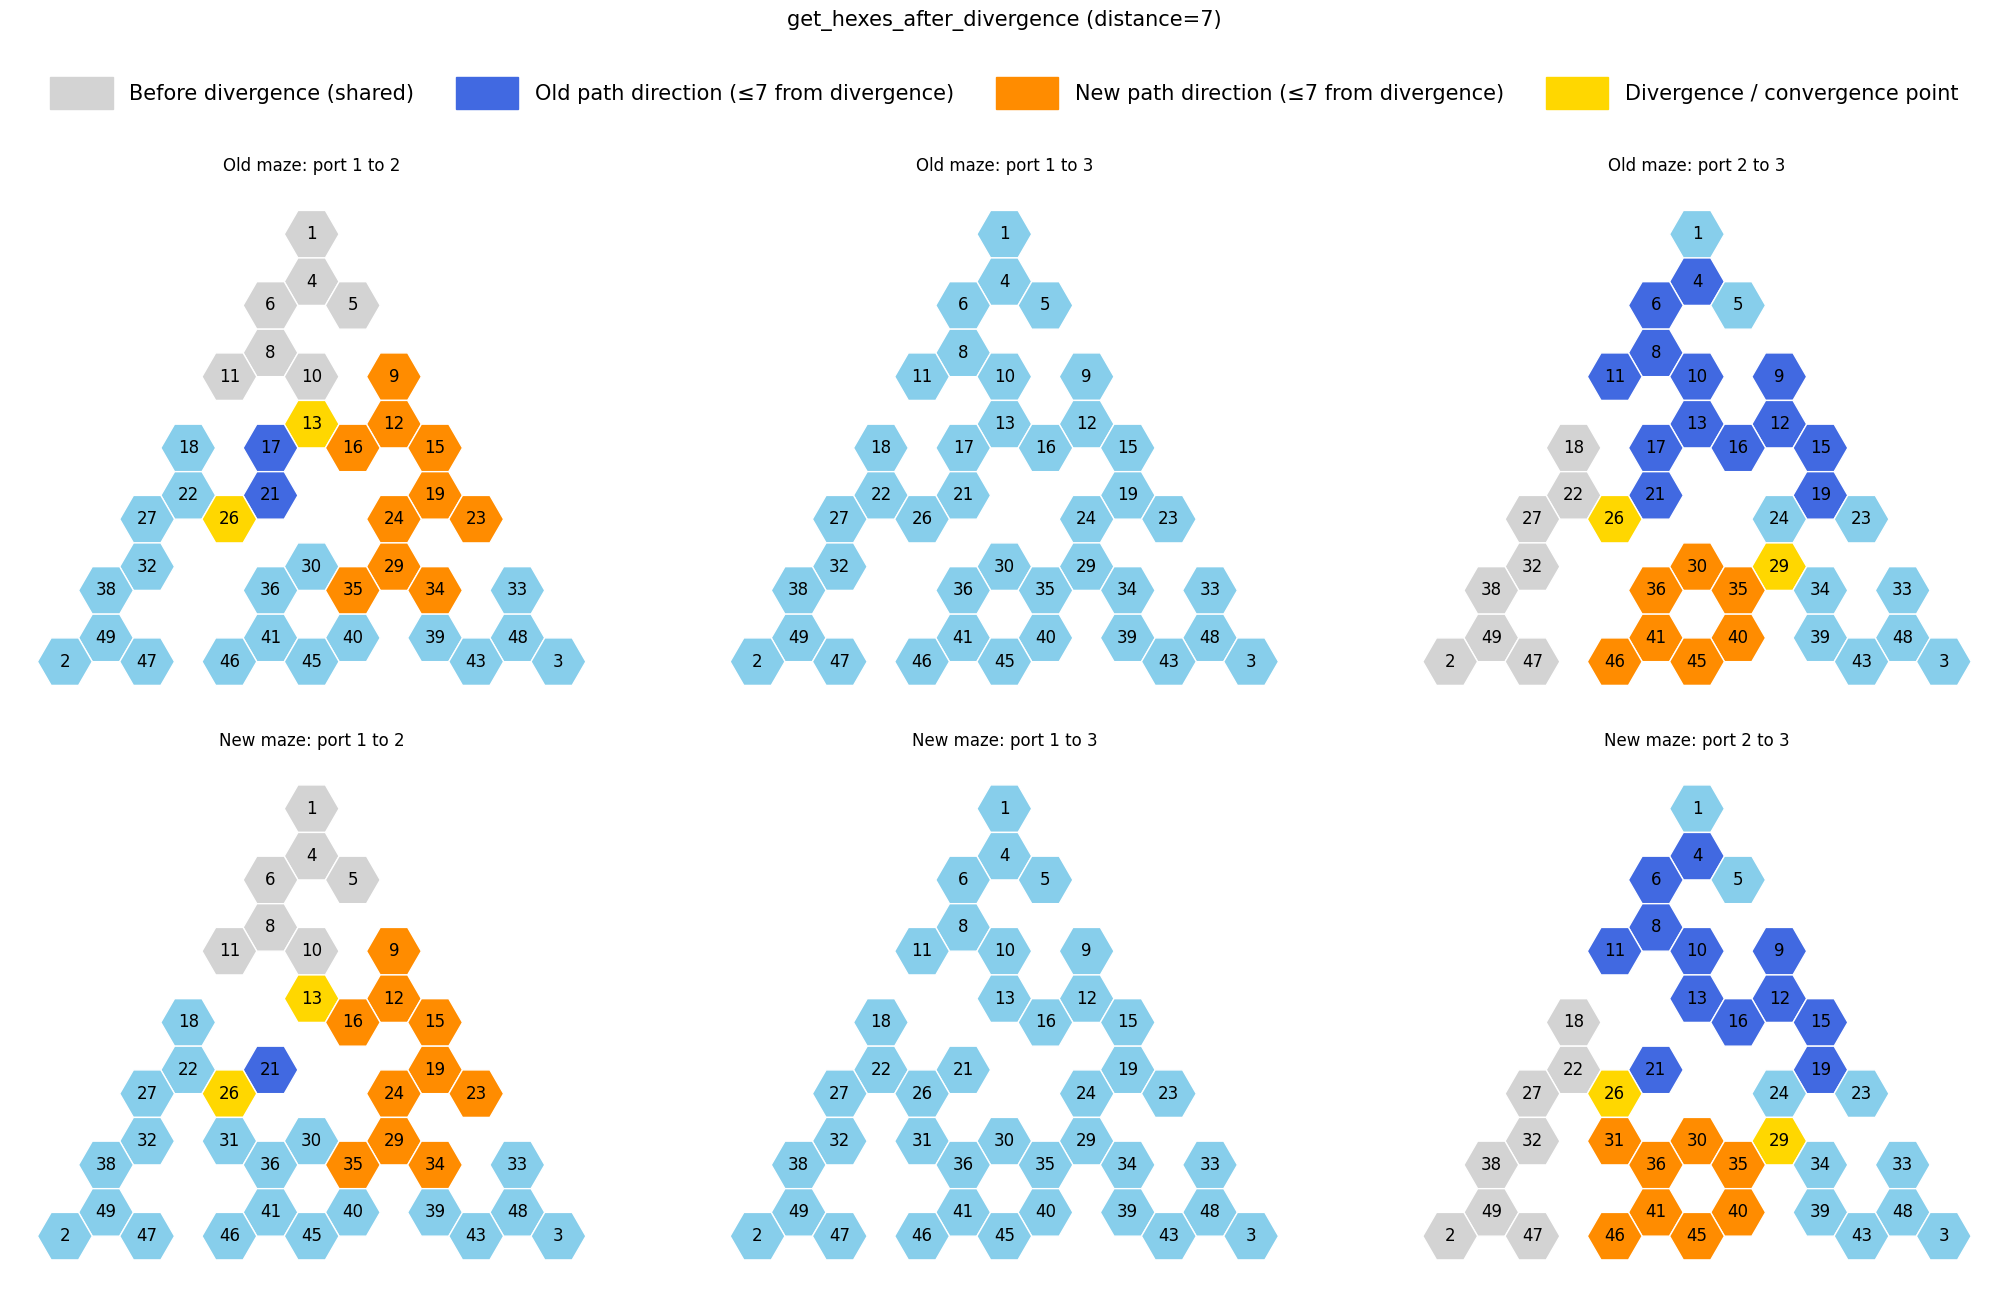

In [3]:
# Load the barrier sequence database for a pair of mazes
barrier_sequence_database = pd.read_pickle('../Barrier_Sequence_Databases/barrier_sequence_database.pkl')
sequence = barrier_sequence_database.iloc[3]['barrier_sequence']
maze_1, maze_2 = sequence[0], sequence[1]

# Show how the BFS region grows with increasing distance from the divergence point
for distance in [3, 5, 7]:
    fig, axes = plt.subplots(2, 3, figsize=(21, 12))

    for i, (start, end) in enumerate([(1, 2), (1, 3), (2, 3)]):
        # Get hexes within `distance` of the divergence point along each path direction
        old_near, new_near = get_hexes_after_divergence(maze_1, maze_2, start, end, distance=distance)
        # Get the shared corridor before divergence for context
        before_div = get_hexes_before_divergence(maze_1, maze_2, start, end)
        # Get divergence/convergence point
        divergence_point = get_path_divergence_point(maze_1, maze_2, start, end)
        convergence_point = get_path_convergence_point(maze_1, maze_2, start, end)

        print(f"Port {start} to Port {end} (distance={distance}):")
        print(f"  Old direction: {old_near}")
        print(f"  New direction: {new_near}")

        key_points = set()
        if divergence_point is not None:
            key_points.add(divergence_point)
        if convergence_point is not None:
            key_points.add(convergence_point)

        # Plot shared corridor in light grey, old BFS region in blue,
        # new BFS region in orange, and divergence/convergence in gold
        highlight = [before_div - key_points, old_near, new_near, key_points]
        colors = ["lightgray", "royalblue", "darkorange", "gold"]

        # Plot on old maze
        plot_hex_maze(maze_1, ax=axes[0, i], highlight_hexes=highlight,
                      highlight_colors=colors, show_hex_labels=True, show_barriers=False)
        axes[0, i].set_title(f"Old maze: port {start} to {end}")

        # Plot on new maze
        plot_hex_maze(maze_2, ax=axes[1, i], highlight_hexes=highlight,
                      highlight_colors=colors, show_hex_labels=True, show_barriers=False)
        axes[1, i].set_title(f"New maze: port {start} to {end}")

    legend_handles = [
        mpatches.Patch(color="lightgray", label="Before divergence (shared)"),
        mpatches.Patch(color="royalblue", label=f"Old path direction (≤{distance} from divergence)"),
        mpatches.Patch(color="darkorange", label=f"New path direction (≤{distance} from divergence)"),
        mpatches.Patch(color="gold", label="Divergence / convergence point"),
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05), fontsize=15,
        handlelength=3, handleheight=2, borderpad=1, frameon=False)
    fig.suptitle(f"get_hexes_after_divergence (distance={distance})", fontsize=15, y=1.08)
    plt.tight_layout()
    plt.show()


# 4. Show old and new optimal paths between ports

`get_old_and_new_paths`: helper to return all optimal paths between two ports on each maze.

Note that this is the same as just calling `get_optimal_paths` for each maze.

Port 1 to Port 2:
  Old maze has 1 optimal path(s): [[1, 4, 5, 7, 9, 12, 16, 20, 24, 29, 35, 40, 45, 41, 36, 31, 37, 42, 47, 49, 2]]
  New maze has 2 optimal path(s): [[1, 4, 5, 7, 10, 13, 17, 14, 18, 22, 26, 31, 37, 42, 47, 49, 2], [1, 4, 6, 8, 10, 13, 17, 14, 18, 22, 26, 31, 37, 42, 47, 49, 2]]
Port 1 to Port 3:
  Old maze has 1 optimal path(s): [[1, 4, 5, 7, 9, 12, 16, 20, 24, 19, 23, 28, 33, 48, 3]]
  New maze has 2 optimal path(s): [[1, 4, 5, 7, 10, 13, 17, 14, 18, 22, 26, 31, 36, 41, 45, 40, 35, 29, 24, 19, 23, 28, 33, 48, 3], [1, 4, 6, 8, 10, 13, 17, 14, 18, 22, 26, 31, 36, 41, 45, 40, 35, 29, 24, 19, 23, 28, 33, 48, 3]]
Port 2 to Port 3:
  Old maze has 1 optimal path(s): [[2, 49, 47, 42, 37, 31, 36, 41, 45, 40, 35, 29, 24, 19, 23, 28, 33, 48, 3]]
  New maze has 1 optimal path(s): [[2, 49, 47, 42, 37, 31, 36, 41, 45, 40, 35, 29, 24, 19, 23, 28, 33, 48, 3]]


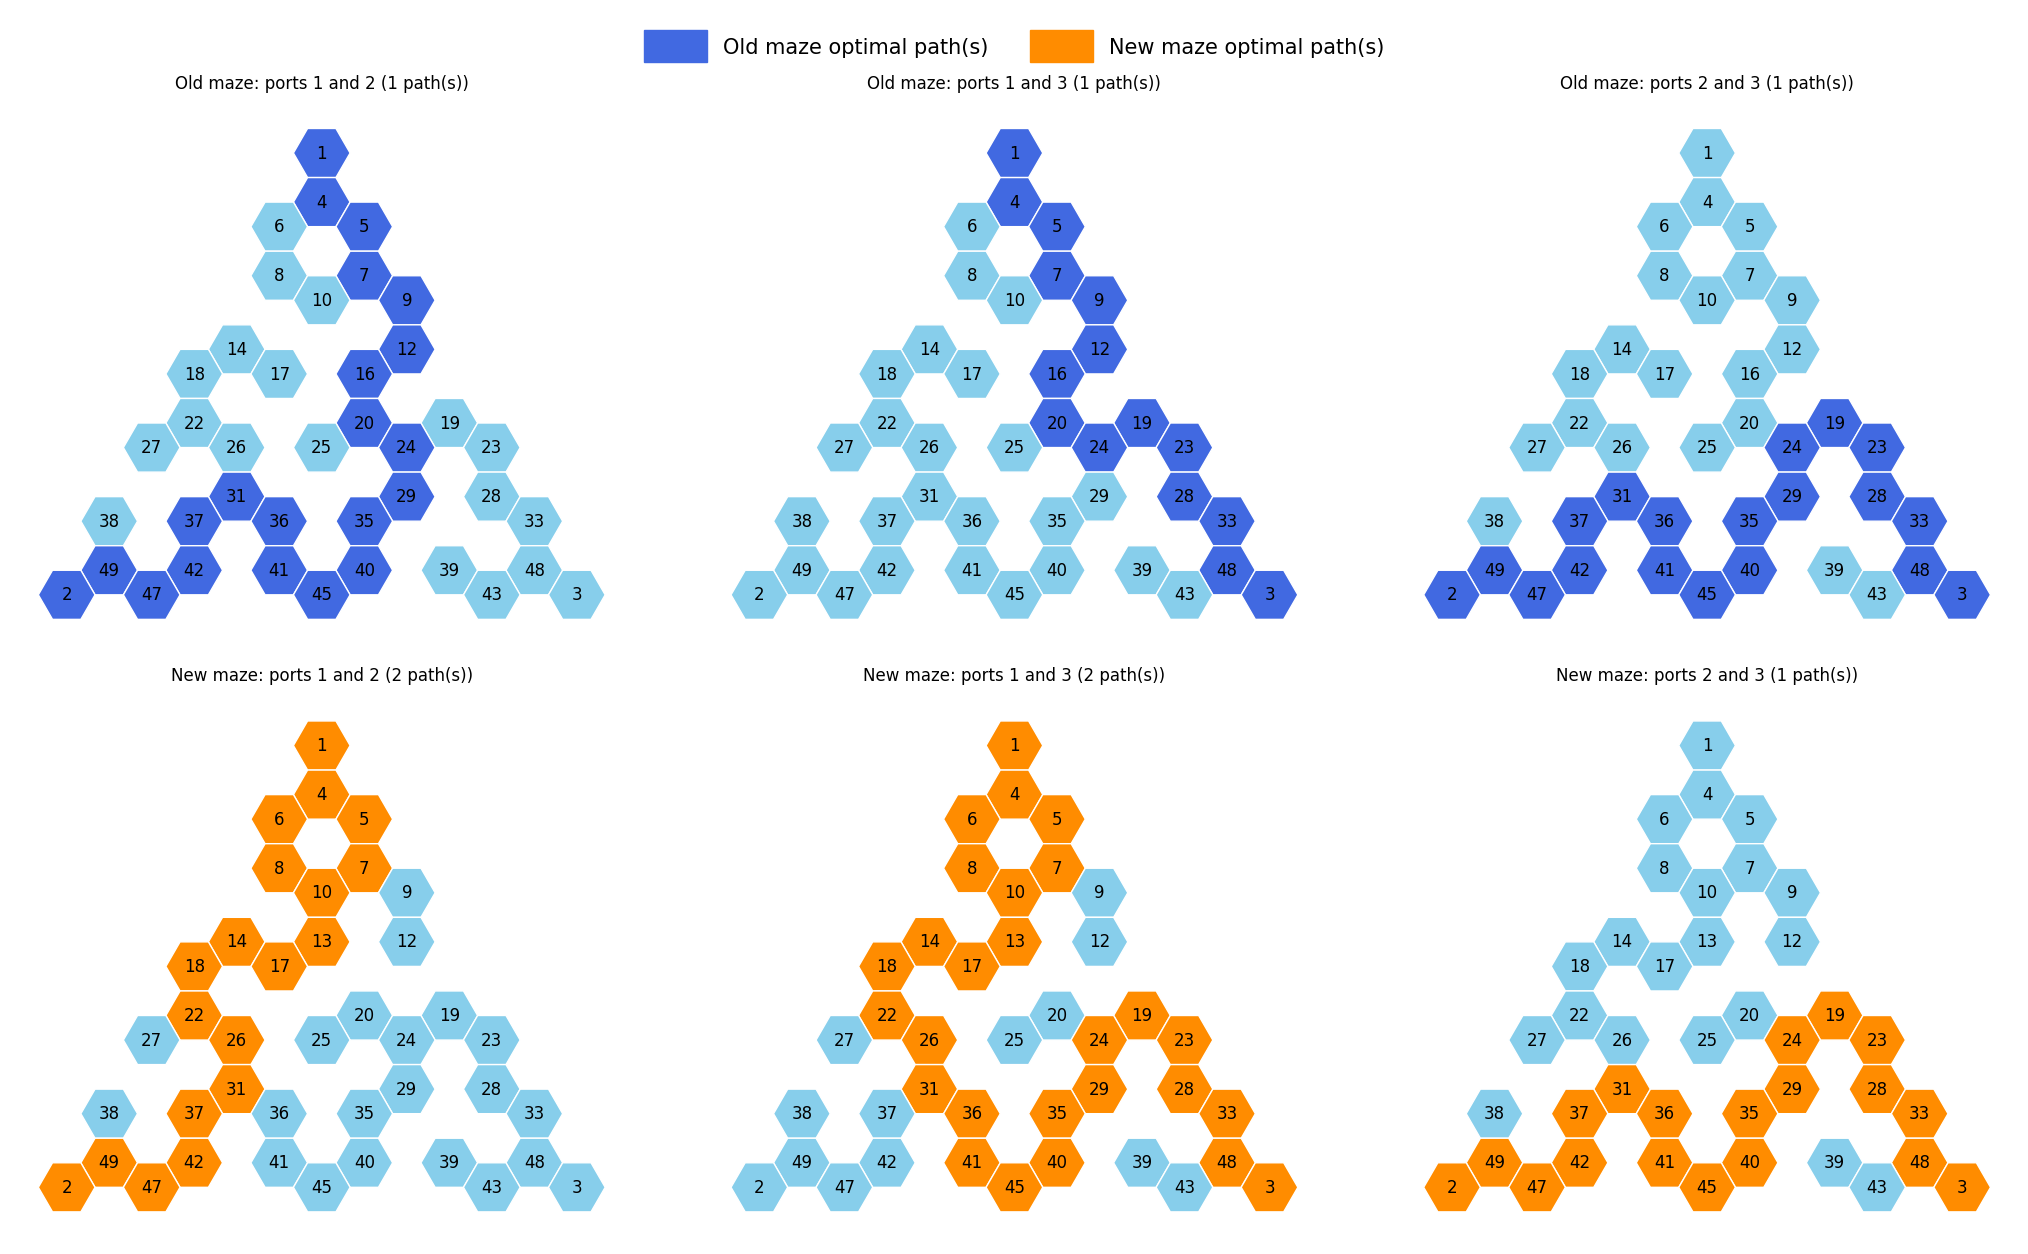

In [4]:
# Grab 2 mazes where one of the mazes has multiple optimal paths
barrier_sequence_database = pd.read_pickle('../Barrier_Sequence_Databases/barrier_sequence_database.pkl')
sequence = barrier_sequence_database.iloc[2]['barrier_sequence']
maze_1, maze_2 = sequence[0], sequence[1]

fig, axes = plt.subplots(2, 3, figsize=(21, 12))

for i, (start, end) in enumerate([(1, 2), (1, 3), (2, 3)]):
    # Get all optimal paths between these ports on each maze
    old_paths, new_paths = get_old_and_new_paths(maze_1, maze_2, start, end)
    print(f"Port {start} to Port {end}:")
    print(f"  Old maze has {len(old_paths)} optimal path(s): {old_paths}")
    print(f"  New maze has {len(new_paths)} optimal path(s): {new_paths}")

    # Combine all old/new paths into highlight sets
    old_path_hexes = {h for path in old_paths for h in path}
    new_path_hexes = {h for path in new_paths for h in path}

    # Plot all old paths on maze 1
    plot_hex_maze(maze_1, ax=axes[0, i], highlight_hexes=[old_path_hexes],
                  highlight_colors=["royalblue"], show_hex_labels=True, show_barriers=False)
    axes[0, i].set_title(f"Old maze: ports {start} and {end} ({len(old_paths)} path(s))")

    # Plot all new paths on maze 2
    plot_hex_maze(maze_2, ax=axes[1, i], highlight_hexes=[new_path_hexes],
                  highlight_colors=["darkorange"], show_hex_labels=True, show_barriers=False)
    axes[1, i].set_title(f"New maze: ports {start} and {end} ({len(new_paths)} path(s))")

legend_handles = [
    mpatches.Patch(color="royalblue", label="Old maze optimal path(s)"),
    mpatches.Patch(color="darkorange", label="New maze optimal path(s)"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize=15,
    handlelength=3, handleheight=2, borderpad=1, frameon=False)
plt.tight_layout()
plt.show()


# 5. Explore all (old, new) path combinations

When a maze has multiple optimal paths, there are multiple ways to pair them (resulting in different path divergence/convergence points). `get_all_path_pairs` returns all (old, new) combinations sorted by similarity (fewest differing hexes first). The most similar pair is what `get_path_divergence_point`, `get_path_convergence_point`, and other functions use by default.


Port 1 to Port 2: 2 path pair(s)


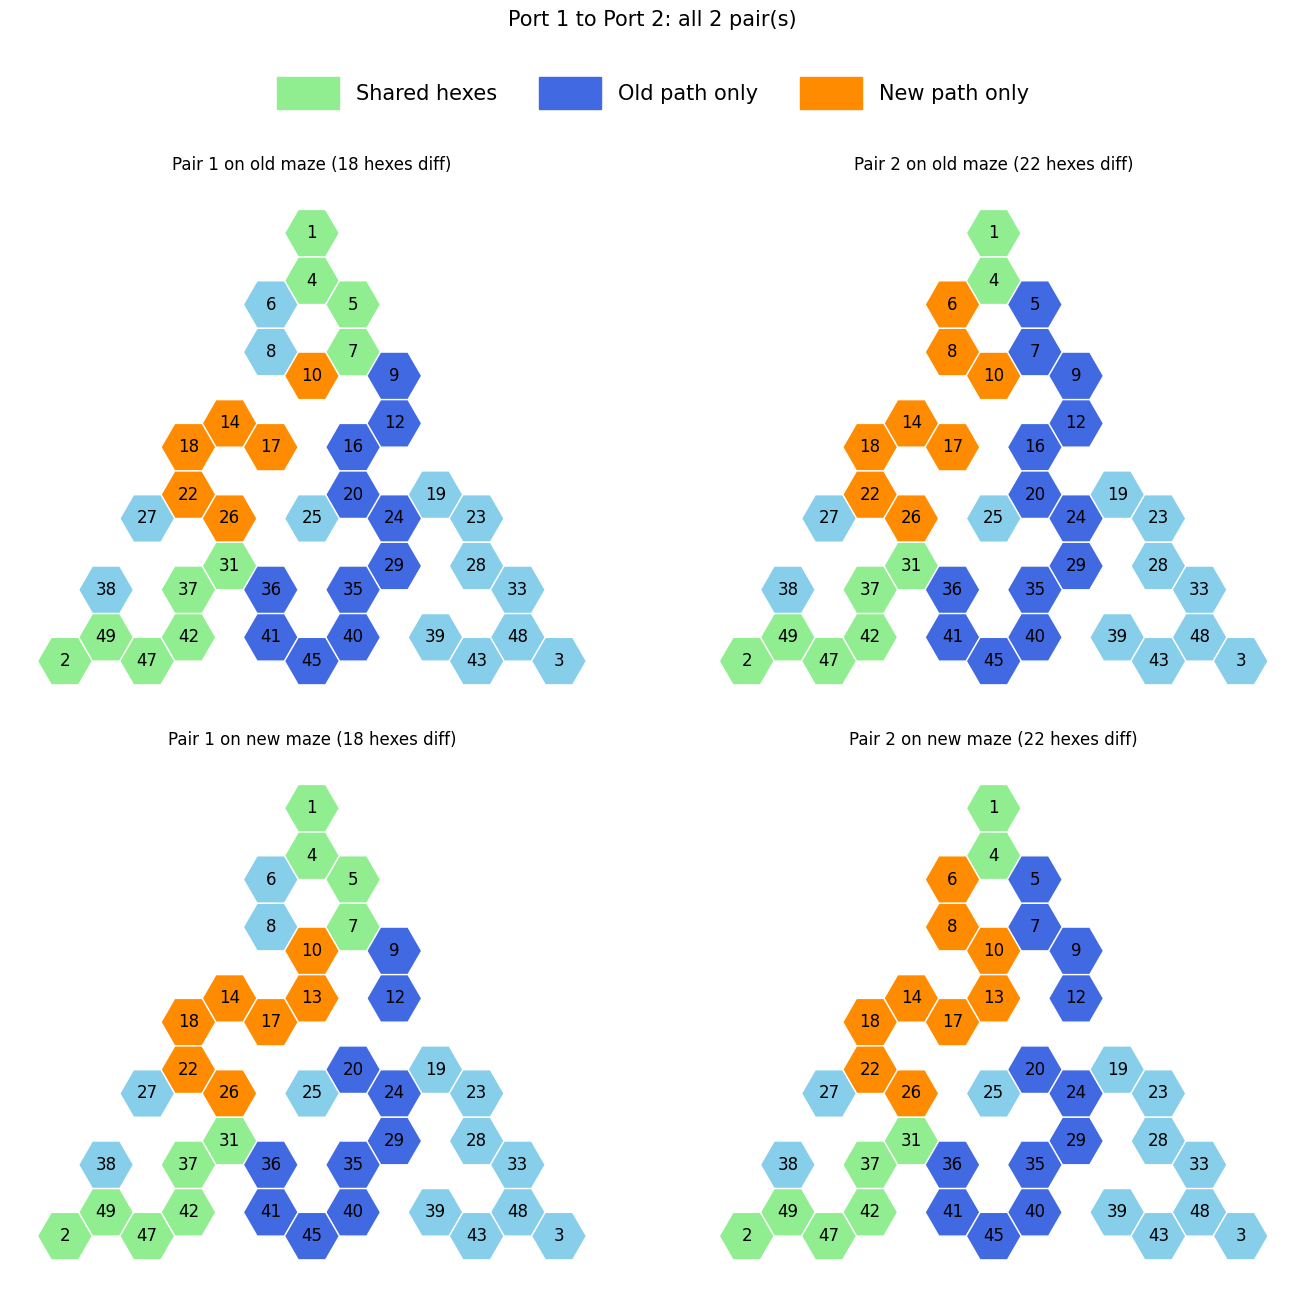

Port 1 to Port 3: 2 path pair(s)


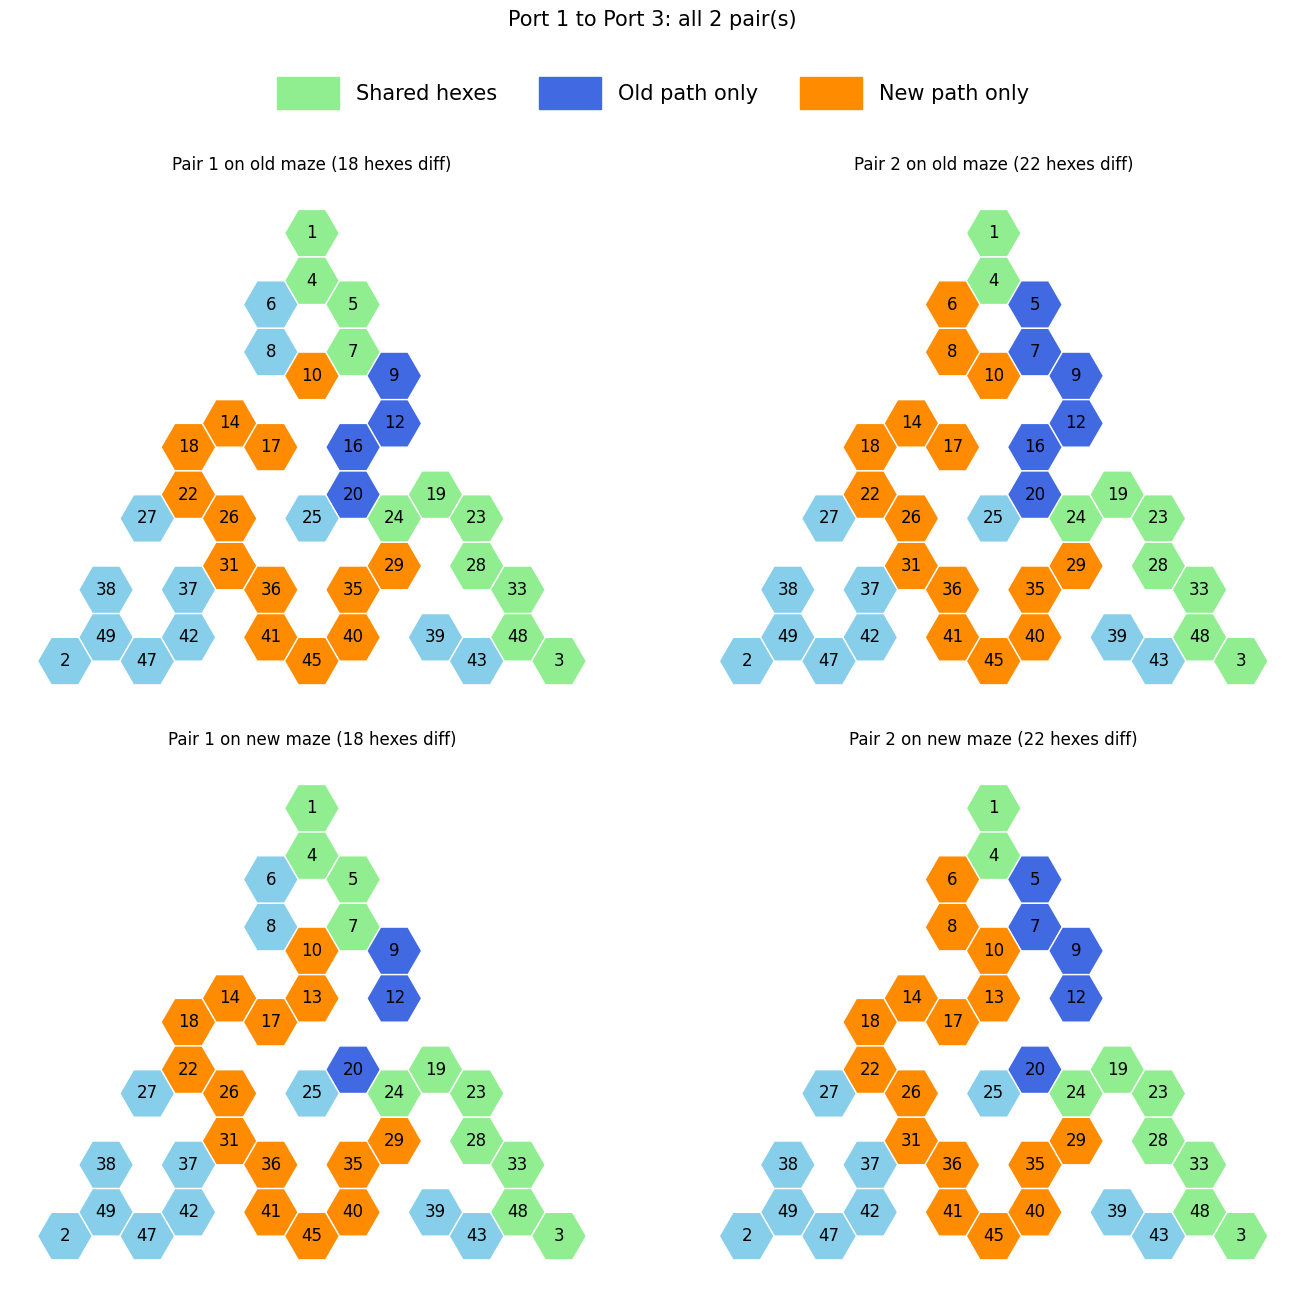

Port 2 to Port 3: 1 path pair(s)


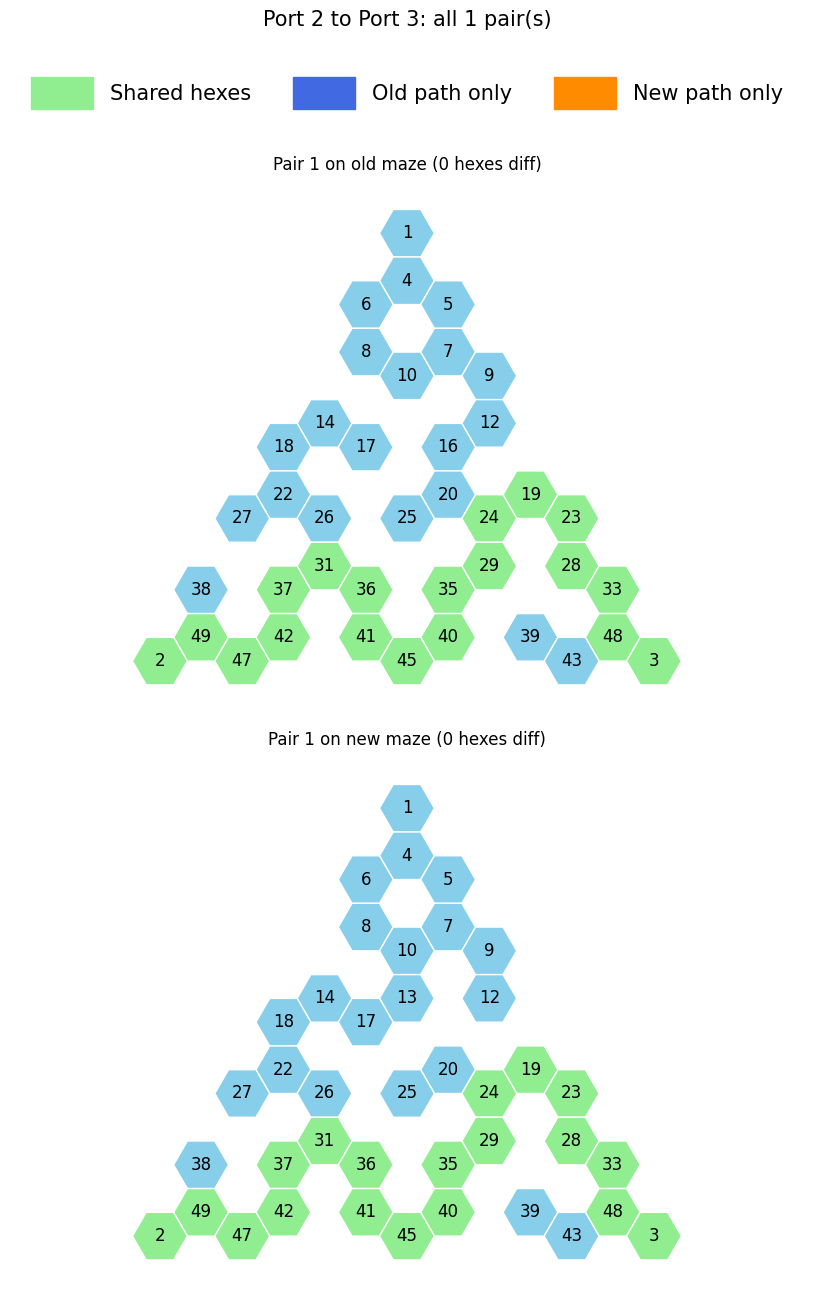

In [5]:
for start, end in [(1, 2), (1, 3), (2, 3)]:
    all_pairs = get_all_path_pairs(maze_1, maze_2, start, end)
    if not all_pairs:
        old_paths, _ = get_old_and_new_paths(maze_1, maze_2, start, end)
        all_pairs = [(old_paths[0], old_paths[0])]

    n_pairs = len(all_pairs)
    print(f"Port {start} to Port {end}: {n_pairs} path pair(s)")

    fig, axes = plt.subplots(2, n_pairs, figsize=(7 * n_pairs, 12))
    if n_pairs == 1:
        axes = axes.reshape(2, 1)

    for j, (old_path, new_path) in enumerate(all_pairs):
        diff = len(set(old_path).symmetric_difference(set(new_path)))
        shared = set(old_path) & set(new_path)
        old_only = set(old_path) - shared
        new_only = set(new_path) - shared

        highlight = [shared, old_only, new_only]
        colors = ["lightgreen", "royalblue", "darkorange"]

        plot_hex_maze(maze_1, ax=axes[0, j], highlight_hexes=highlight,
                      highlight_colors=colors, show_hex_labels=True, show_barriers=False)
        axes[0, j].set_title(f"Pair {j+1} on old maze ({diff} hexes diff)")

        plot_hex_maze(maze_2, ax=axes[1, j], highlight_hexes=highlight,
                      highlight_colors=colors, show_hex_labels=True, show_barriers=False)
        axes[1, j].set_title(f"Pair {j+1} on new maze ({diff} hexes diff)")

    legend_handles = [
        mpatches.Patch(color="lightgreen", label="Shared hexes"),
        mpatches.Patch(color="royalblue", label="Old path only"),
        mpatches.Patch(color="darkorange", label="New path only"),
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05), fontsize=15,
        handlelength=3, handleheight=2, borderpad=1, frameon=False)
    fig.suptitle(f"Port {start} to Port {end}: all {n_pairs} pair(s)", fontsize=15, y=1.08)
    plt.tight_layout()
    plt.show()
